Using ThinCurr to predict forces from a simple CQ
==========
The purpose of this notebook is to a demonstrate modeling a simple CQ and computing the resulting forces on device structures using TokaMaker.

This example is based on one available in the main documentation here: [TokaMaker Example: Predicting currents and forces induced during a CQ in ITER](https://openfusiontoolkit.github.io/OpenFUSIONToolkit/docs/v26.6/doc_tMaker_ITER_ex5.html) and utilizes the SPARC model created in [TokaMaker Meshing Example: Building a mesh for SPARC](https://openfusiontoolkit.github.io/OpenFUSIONToolkit/docs/latest/doc_tMaker_SPARC_ex1.html)

## Setup Python environment

First, we setup some environment-specific things to allow this example to be run locally or via [Google Colab](https://colab.research.google.com/).

If the Open FUSION Toolkit is build from source instead of installed using `pip`, we also need to tell python where to the module is located. The best way to do this is through the `PYTHONPATH` environment variable or using a dedicated environement variable (eg. `OFT_ROOTPATH`) to provide the path to where the OpenFUSIONToolkit is installed and passing this to `sys.path.append()` as below.

In [1]:
import os
try:
    from google.colab import output
    output.enable_custom_widget_manager()
    on_google_colab = True
except:
    import sys
    tokamaker_python_path = os.getenv('OFT_ROOTPATH')
    if tokamaker_python_path is not None:
        sys.path.append(os.path.join(tokamaker_python_path,'python'))
    on_google_colab = False
    pass
else:
    print("Google collab detected:")
    %cd /content
    !pip install -q wurlitzer ipympl openfusiontoolkit pyvista
    if not os.path.exists('OpenFUSIONToolkit-Tutorials/OSSFE-2026'):
        !git clone -b MiRACL26 --single-branch --depth 1 https://github.com/OpenFUSIONToolkit/OpenFUSIONToolkit-Tutorials
        #!git clone --depth 1 https://github.com/OpenFUSIONToolkit/OpenFUSIONToolkit-Tutorials
    %cd OpenFUSIONToolkit-Tutorials/MiRACL-2026
    %load_ext wurlitzer
%matplotlib inline
%config InlineBackend.figure_format = "retina"

### Load standard Python modules
Now that TokaMaker is installed an in our Python path we can load the required modules

In [2]:
import json
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pyvista
pyvista.set_jupyter_backend('static') # Comment to enable interactive PyVista plots
plt.rcParams['figure.figsize']=(6,6)
plt.rcParams['font.weight']='bold'
plt.rcParams['axes.labelweight']='bold'
plt.rcParams['lines.linewidth']=2
plt.rcParams['lines.markeredgewidth']=2
%matplotlib inline
%config InlineBackend.figure_format = "retina"

### Load OFT modules
Now we can load the required modules from the Open Fusion Toolkit

In [3]:
from OpenFUSIONToolkit import OFT_env
from OpenFUSIONToolkit.ThinCurr import ThinCurr
from OpenFUSIONToolkit.ThinCurr.sensor import Mirnov, save_sensors
from OpenFUSIONToolkit.ThinCurr.coils import ThinCurr_Icoil, ThinCurr_XML
from OpenFUSIONToolkit.io import histfile, write_oft_xml

## Initialize OFT environment
Now we create the runtime environment for the Open FUSION Toolkit. Only one environment ([OFT_env](https://openfusiontoolkit.github.io/OpenFUSIONToolkit/docs/v26.6/classOpenFUSIONToolkit_1_1__core_1_1OFT__env.html)) can be instantiated per python kernel. Within OFT parallelism is enabled through the use of OpenMP, so the number of threads to be used is also set at this time.

**Note:** As with any computationally intensive code, if you try and use more threads than the number of processors performance will degrade significantly due to contention. So we use only one thread on Google Colab where the default environment has only one virtual cpu core.

**Warning:** This ThinCurr model is much more computationally intensive than the TokaMaker examples and may take a fairly long time to run on Google Colab due to limited compute resources.

In [4]:
if on_google_colab:
    myOFT = OFT_env(nthreads=1)
else:
    myOFT = OFT_env(nthreads=4)

#----------------------------------------------
             ____  ____________
            / __ \/ ____/_  __/
           / / / / /_    / /
          / /_/ / __/   / /
          \____/_/     /_/

Release version:  v26.6

Parallelization Info:
  Not compiled with MPI
  # of OpenMP threads =    4

Linear Algebra backend: native

#----------------------------------------------



## Build ThinCurr model
To build a ThinCurr model of a machine we need to components:
 1. A mesh for the conducting structures, which is usually generated in an external meshing tool directly from CAD information. In this example, we use Cubit and the information in the [SPARC public repo](https://github.com/cfs-energy/SPARCPublic/) along with an approximate representation of the midplane ports based on publicly available publications (eg. [Battey et al. (2024)](https://doi.org/10.1088/1741-4326/ad0bcf)).
 2. An XML file that defines material parameters (eg. resistivity, thickness) and coils, which can be either current-controlled (`Icoils`) or voltage-controlled (`Vcoils`).

For more information see the [ThinCurr documentation](https://openfusiontoolkit.github.io/OpenFUSIONToolkit/docs/v26.6/doc_tw_main.html)

Cubit is available in two forms, one for US government-funded research [directly from Sandia National Lab](https://cubit.sandia.gov/) (license agreement required) and one from [CoreForm](https://coreform.com/coreform-cubit/), which includes a free educational version (sign up required). Other open meshing programs, such as [GMSH](https://gmsh.info/) and [Salome](https://www.salome-platform.org/) can generate appropriate meshes, but interfacing to ThinCurr needs development for parity with Cubit (help always appreciated).

### Write ThinCurr XML model file
Here we build the XML file programatically within the notebook by adding the resistivity information, PF coils, and plasma current filaments defined in [Using TokaMaker to predict forces from a simple CQ](https://github.com/OpenFUSIONToolkit/OpenFUSIONToolkit-Tutorials/blob/MiRACL26/MiRACL-2026/TokaMaker-disruption_forces.ipynb).

In [5]:
xml = ThinCurr_XML()

with open('SPARC_public_simple.json','r') as fid:
    SPARC_geom = json.load(fid)

with open('EQ_currents.json','r') as fid:
    EQ_currents = json.load(fid)

# Set resistivities
xml.set_eta([
    SPARC_geom['vv']['inner']['eta']/SPARC_geom['vv']['inner']['thickness'],
    SPARC_geom['vv']['outer']['eta']/SPARC_geom['vv']['outer']['thickness']
])

# Create PF coils
coil_filament_currents = []
for name, sub_coils in SPARC_geom['coils'].items():
    coil_tmp = ThinCurr_Icoil(name=name)
    for sub_coil in sub_coils:
        coil_tmp.add_subcoil(RZ=np.r_[sub_coil[0], sub_coil[1]])
    xml.add_Icoil(coil_tmp)
    coil_filament_currents.append(EQ_currents[name])

# Create Plasma coils
EQ_filaments = np.loadtxt('EQ_filaments.dat')
for i in range(EQ_filaments.shape[0]):
    coil_tmp = ThinCurr_Icoil(name='Plasma_{0}'.format(i+1))
    coil_tmp.add_subcoil(RZ=np.r_[EQ_filaments[i,0], EQ_filaments[i,1]])
    xml.add_Icoil(coil_tmp)

# Write XML file
write_oft_xml([xml], "SPARC_ThinCurr.xml")

XML file created at SPARC_ThinCurr.xml


### Initialize ThinCurr
Now we create a [ThinCurr](https://openfusiontoolkit.github.io/OpenFUSIONToolkit/docs/v26.6/classOpenFUSIONToolkit_1_1ThinCurr_1_1__core_1_1ThinCurr.html) solver instance and set it up by calling [setup_model](https://openfusiontoolkit.github.io/OpenFUSIONToolkit/docs/v26.6/classOpenFUSIONToolkit_1_1ThinCurr_1_1__core_1_1ThinCurr.html#a8f82d1cfd87fa3b30f33388028cb5da6) to define the grid/regions and setup the required finite element represention and solver objects.

We also initialize I/O for this model using [setup_io()](https://openfusiontoolkit.github.io/OpenFUSIONToolkit/docs/v26.6/classOpenFUSIONToolkit_1_1ThinCurr_1_1__core_1_1ThinCurr.html#a2e3385e16c1d7303cae52460e68ac85f)" to enable output of plotting files for 3D visualization in [Paraview](https://www.paraview.org/) or using [pyvista](https://pyvista.org/) within the notebook.

In [6]:
tw_SPARC = ThinCurr(myOFT)
tw_SPARC.setup_model(mesh_file='SPARC_public-ThinCurr_approx-homology.h5',xml_filename='SPARC_ThinCurr.xml')
tw_SPARC.setup_io()


Creating thin-wall model
  No V(t) driver coils found
  Loading I(t) driver coils
    Masked      0 coils from sensors
  Building holes

  Loading region surface resistivity:
     1  2.6667E-05
     2  2.0000E-05

  Setup complete:
    # of points    =        22456
    # of edges     =        66252
    # of cells     =        43760
    # of holes     =           38
    # of closures  =            0
    # of Vcoils    =            0
    # of Icoils    =          694


### Compute inductance and resistivity matrices
With the model setup, we can now compute the required matrices for the system we wish to solve. ThinCurr always solves some variant of resistive-inductive dynamics given by

$\textrm{L} \frac{\partial I}{\partial t} + \textrm{R} I = V.$

For this current quench simulation, the RHS voltage will come from the changing plasma current as $V = M_C \frac{\partial I_C}{\partial t}$, where $M_C$ is the mutual matrix from the coils to the conducting structures (VV in our case).

To build the required matrices we use [compute_Mcoil()](https://openfusiontoolkit.github.io/OpenFUSIONToolkit/docs/v26.6/classOpenFUSIONToolkit_1_1ThinCurr_1_1__core_1_1ThinCurr.html#abf7cfc1e5cb5a643a1e2c82948139958), [compute_Lmat()](https://openfusiontoolkit.github.io/OpenFUSIONToolkit/docs/v26.6/classOpenFUSIONToolkit_1_1ThinCurr_1_1__core_1_1ThinCurr.html#a7b5cfb558ae70a1aa9f3adacc889f2d4), and [compute_Rmat()](https://openfusiontoolkit.github.io/OpenFUSIONToolkit/docs/v26.6/classOpenFUSIONToolkit_1_1ThinCurr_1_1__core_1_1ThinCurr.html#a50f692df2e7d62c319fc9c7a004cfeb8). Additionally, we build the magnetic field reconstruction operator using [compute_Bmat()](https://openfusiontoolkit.github.io/OpenFUSIONToolkit/docs/v26.6/classOpenFUSIONToolkit_1_1ThinCurr_1_1__core_1_1ThinCurr.html#af1280995c84e1198946403b549fa7516), which enables evaluating the magnetic field on conducting structures for force calculations.

The inductance ($L$) and B-field operators are dense matrices, which can lead to very large systems, so we use an approach called Hierarchical Off-Diagonal Low-Rank (HODLR) approximation to approximate the matrix in an efficient and error-bounded way. This approach is similar to the fast multipole method, but uses the matrix itself instead of explicitly grouping physical sources.

**Note:** Even though HODLR should significantly accelerate the construction of the self-inductance matrix (see [ThinCurr Python Example: Using HODLR approximation](https://openfusiontoolkit.github.io/OpenFUSIONToolkit/docs/v26.6/doc_tCurr_hodlr.html) for more information) this process may still take some time to complete.

**Note:** The non-zero savings achieved by HODLR compression is reported after the operator is built. Where in this case only 9% of the original memory is needed resulting in a reduction from > 3.5 GB to ~ 330 MB (over 10x smaller)!

In [7]:
if on_google_colab:
    Mc = tw_SPARC.compute_Mcoil()
    tw_SPARC.compute_Lmat(use_hodlr=True)
    print()
    tw_SPARC.compute_Bmat()
else:
    Mc = tw_SPARC.compute_Mcoil(cache_file='Mcoil.save')
    tw_SPARC.compute_Lmat(use_hodlr=True,cache_file='HOLDR_L.save')
    print()
    tw_SPARC.compute_Bmat(cache_file='HOLDR_B.save')
tw_SPARC.compute_Rmat()

Reading coil mutual matrices
 Partitioning grid for block low rank compressed operators
   nBlocks =                  32
   Avg block size =          663
   # of SVD =                230
   # of ACA =                209

 Building block low rank inductance operator
   Building hole and Vcoil columns
   Reading HODLR matrix from file: HOLDR_L.save
   Building diagonal blocks
     10%
     20%
     30%
     40%
     50%
     60%
     70%
     80%
     90%
   Building off-diagonal blocks using ACA+
     10%
     20%
     30%
     40%
     50%
     60%
     70%
     80%
     90%
     Compression ratio:   9.4%  ( 4.23E+07/ 4.51E+08)
     Time =  8s          

 Building block low rank magnetic field operator
   Building hole and Vcoil columns
   Reading HODLR matrix from file: HOLDR_B.save
   Building diagonal blocks
     10%
     20%
     30%
     40%
     50%
     60%
     70%
     80%
     90%
   Building off-diagonal blocks using ACA+
     10%
     20%
     30%
     40%
     50%
     60%

## Run time-domain simulation
With the model fully defined we can now use [run_td()](https://openfusiontoolkit.github.io/OpenFUSIONToolkit/docs/v26.6/classOpenFUSIONToolkit_1_1ThinCurr_1_1__core_1_1ThinCurr.html#aba8f91fb65c529149d6be8624ec3a3ce) to perform a time-domain simulation. In this case we simulate the same ~70 ms simulated in the TokaMaker example using a timestep of 150 $\mu$s (470 steps).

By default the time-domain simulation starts with zero current in the conducting structures. For coils, the time-waveforms of current and voltage must be specified for `Icoils` and `Vcoils` respectively. In this case, we are only using `Icoils` so we just specify coil currents, where the PF coil currents are constant and the plasma currents maintain the distribution computed in the TokaMaker example with a linear ramp over 3 ms as in the TokaMaker simple CQ example.

We also increase the default solver tolerances slightly and set output to be saved every step for post-processing and comparisons to follow.

In [8]:
CQ_time = 3.E-3

dt = CQ_time/20.0
nsteps = 470

coil_currs = np.zeros((nsteps//4,tw_SPARC.n_icoils+1))
coil_currs[:,0] = np.linspace(0.0,dt*(nsteps-1),nsteps//4)
for i, coil_current in enumerate(coil_filament_currents):
    coil_currs[:,i+1] = coil_current

CQ_ramp = 1.0-np.minimum(coil_currs[:,0]/CQ_time,1.0)
for i, filament_current in enumerate(EQ_filaments[:,2]):
    coil_currs[:,i+len(coil_filament_currents)+1] = filament_current*CQ_ramp
    
tw_SPARC.run_td(dt,nsteps,status_freq=10,plot_freq=1,coil_currs=coil_currs,lin_tol=1.E-8,lin_rtol=1.E-5)


Starting time-domain simulation
  timestep    time           sol_norm     nits    solver time
      10    1.500000E-03    1.2538E+02     105        0.58
      20    3.000000E-03    2.3073E+02     103        0.59
      30    4.500000E-03    2.0960E+02      99        0.56
      40    6.000000E-03    1.9672E+02      96        0.54
      50    7.500000E-03    1.8975E+02      95        0.64
      60    9.000000E-03    1.8528E+02      91        0.52
      70    1.050000E-02    1.8192E+02      89        0.50
      80    1.200000E-02    1.7906E+02      87        0.49
      90    1.350000E-02    1.7644E+02      88        0.50
     100    1.500000E-02    1.7394E+02      86        0.60
     110    1.650000E-02    1.7151E+02      84        0.48
     120    1.800000E-02    1.6911E+02      85        0.53
     130    1.950000E-02    1.6673E+02      86        0.49
     140    2.100000E-02    1.6438E+02      85        0.49
     150    2.250000E-02    1.6206E+02      85        0.49
     160    2.400000

## Post-process simulation
After running the calculation we now post-process the results using [plot_td()](https://openfusiontoolkit.github.io/OpenFUSIONToolkit/docs/v26.6/classOpenFUSIONToolkit_1_1ThinCurr_1_1__core_1_1ThinCurr.html#a96e17722b6cadd53543f0fc0871abc68) to generate plot data that includes the reconstructed current and magnetic field on the computational grid. After this we use [build_XDMF()](https://openfusiontoolkit.github.io/OpenFUSIONToolkit/docs/v26.6/classOpenFUSIONToolkit_1_1ThinCurr_1_1__core_1_1ThinCurr.html#a841a7e2c58ab3642569eef11853a14ab) to build descriptor files that enable the data to be read by visualization tools such as [ParaView](https://www.paraview.org/). This method also returns an object that can be used to access this data in Python for the further analysis and inline plotting below.

In [9]:
tw_SPARC.plot_td(nsteps,compute_B=True,plot_freq=1)
plot_data = tw_SPARC.build_XDMF()
ThinCurr_mesh = plot_data['ThinCurr']['smesh']


Post-processing time-domain simulation


/usr/local/Python_venv/OFT_26_6/bin/python: can't open file '/usr/local/Python_venv/OFT_26_6/lib/python3.13/site-packages/OpenFUSIONToolkit/../build_xdmf.py': [Errno 2] No such file or directory


### Plot computational grid
Using this object together with [PyVista](https://pyvista.org/) we can plot the computational grid and coil/plasma filaments.

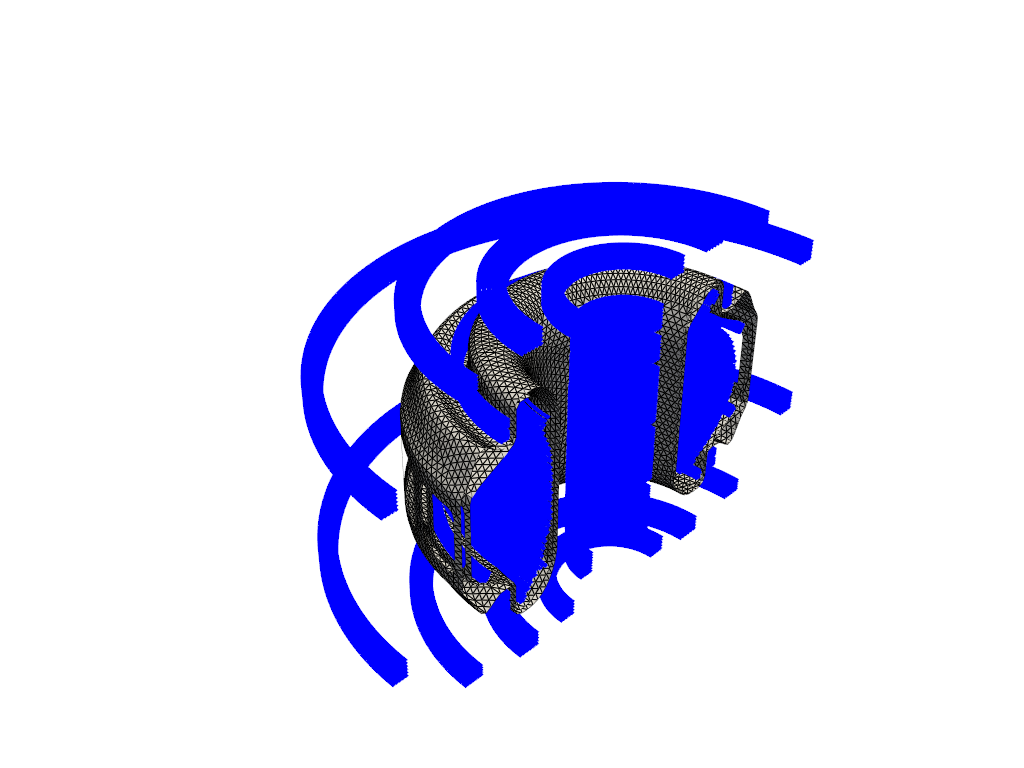

In [10]:
icoil_grid = plot_data['ThinCurr']['icoils'].get_pyvista_grid()
grid = ThinCurr_mesh.get_pyvista_grid()
p = pyvista.Plotter()
p.add_mesh(grid.clip("y", invert=True), color="white", opacity=1.0, show_edges=True)
p.add_mesh(icoil_grid.clip("y", invert=True), color="blue", opacity=1.0, line_width=4)
p.show()

### Plot current distribution
In a similar way we can also plot the current distribution on the conducting surfaces. Here we choose 35 ms, which is near the peak force as we will se below.

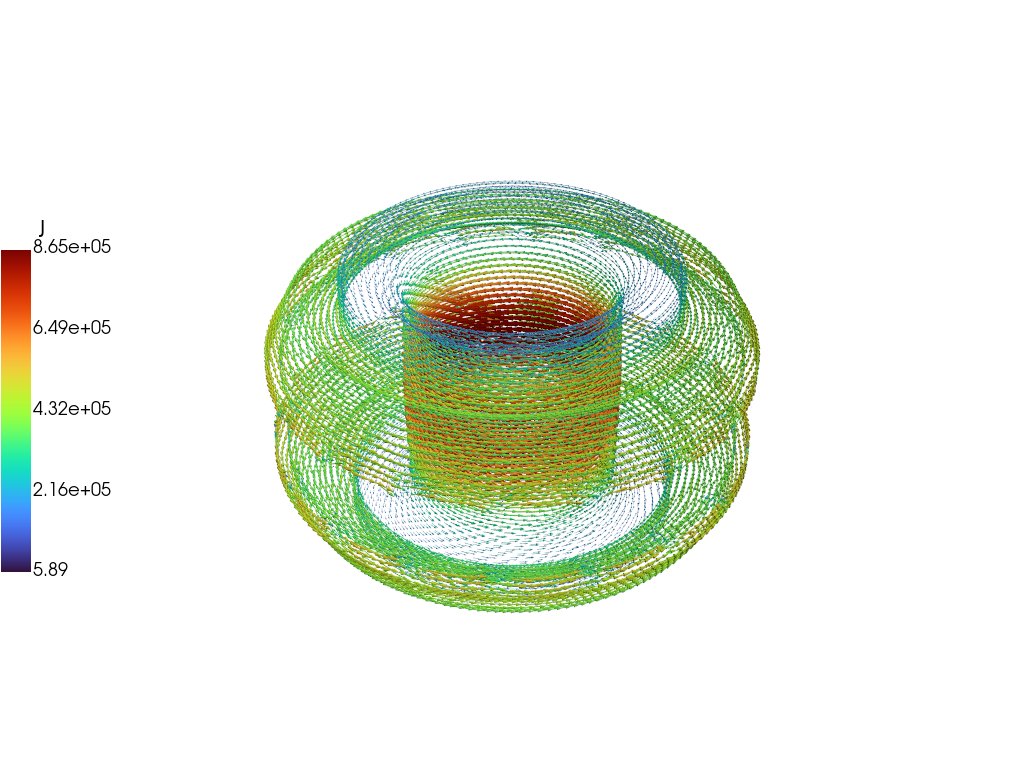

In [11]:
# Get current field at specified time
J = ThinCurr_mesh.get_field('J_v',35.E-3)

# Plot mesh and current density using PyVista
p = pyvista.Plotter()
grid["vectors"] = J
grid.set_active_vectors("vectors")
scale = 0.4/(np.linalg.norm(J,axis=1)).max()
arrows = grid.glyph(scale="vectors", orient="vectors", factor=scale)
p.add_mesh(arrows, cmap="turbo", scalar_bar_args={'title': "|J|", "vertical": True, "position_y":0.25, "position_x": 0.0})
p.show()

### Plot force distribution
We can do the same thing for the force density distribution by computing $J \times B$ from the plotting fields.

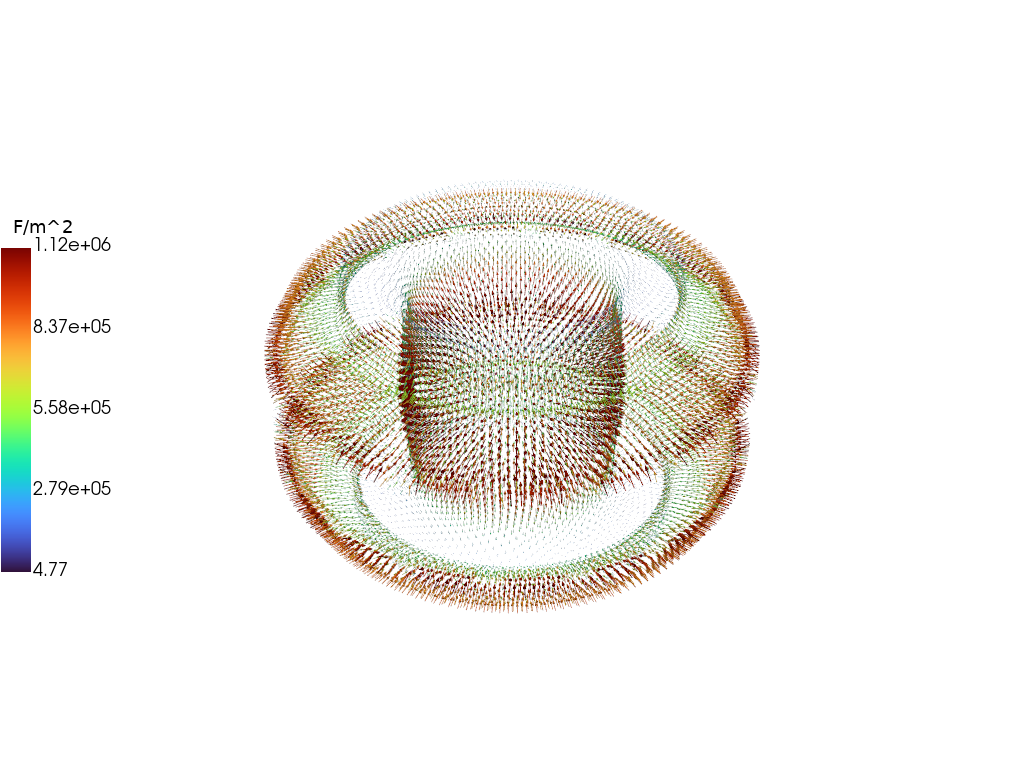

In [12]:
# Compute force density at specified time
J = ThinCurr_mesh.get_field('J_v',35.E-3)
B = ThinCurr_mesh.get_field('B_v',35.E-3)
P = np.cross(J,B,axis=1)

# Plot mesh and force density using PyVista
p = pyvista.Plotter()
grid["vectors"] = P
grid.set_active_vectors("vectors")
scale = 0.2/(np.linalg.norm(P,axis=1)).max()
arrows = grid.glyph(scale="vectors", orient="vectors", factor=scale)
p.add_mesh(arrows, cmap="turbo", scalar_bar_args={'title': "|F/m^2|", "vertical": True, "position_y":0.25, "position_x": 0.0})
p.show()

## Compute forces on conducting structures
In addition to plotting we can also use the post-processed fields to compute the force over regions of the grid. To do this we must integrate the force density to get a net force on the given region.

First though, we need some additional information, including the area of each cell (triangle) and the radial unit vector, which we will use to extract a hoop "force". For ThinCurr's triangular grid these can be readily computed from the information in the plotting mesh.

In [13]:
area = np.zeros((ThinCurr_mesh.nc,))
rhat = np.zeros((ThinCurr_mesh.nc,3))
for i in range(ThinCurr_mesh.nc):
    # Get two edges of triangle
    v1 = ThinCurr_mesh.r[ThinCurr_mesh.lc[i,1],:]-ThinCurr_mesh.r[ThinCurr_mesh.lc[i,0],:]
    v2 = ThinCurr_mesh.r[ThinCurr_mesh.lc[i,2],:]-ThinCurr_mesh.r[ThinCurr_mesh.lc[i,0],:]
    # Compute area of triangle
    area[i] = np.linalg.norm(np.cross(v1,v2))/2.0
    # Compute radial unit normal
    rcc = (ThinCurr_mesh.r[ThinCurr_mesh.lc[i,2],:]+ThinCurr_mesh.r[ThinCurr_mesh.lc[i,1],:]+ThinCurr_mesh.r[ThinCurr_mesh.lc[i,0],:])/3.0
    rhat[i,:2] = rcc[:2]/np.linalg.norm(rcc[:2])

Next we define a helper function, which computes the desired net forces from a cell-centered current density and vertex-centered magnetic field, which we will retrieve from the plot files. The function also supports an optional cell mask, which can be used to restrict the force calculation to specific areas. In this example we will use this to mask the calculation based on the region ID, but many other filterings are possible (eg. position-based).

In [14]:
def compute_force(J_cc,B_v,cell_mask=None):
    B_cc = (B_v[ThinCurr_mesh.lc[:,0],:]+B_v[ThinCurr_mesh.lc[:,1],:]+B_v[ThinCurr_mesh.lc[:,2],:])/3.0
    B_cc = B_cc*area[:,None] # Scale by area for faster integration
    if cell_mask is None:
        F_cc = np.cross(J_cc,B_cc,axis=1)
        Fh = np.sum(F_cc*rhat,axis=None)
    else:
        F_cc = np.cross(J_cc[cell_mask,:],B_cc[cell_mask,:],axis=1)
        Fh = np.sum(F_cc*rhat[cell_mask,:],axis=None)
    return np.r_[np.sum(F_cc,axis=0), Fh]

With this information and functionality we can now loop over the desired time points and compute the force at each time.

In [15]:
times = np.linspace(0.0,dt*nsteps,nsteps+1,endpoint=False)
forces_inner = np.zeros((times.shape[0], 4))
forces_outer = np.zeros((times.shape[0], 4))
for i, time in enumerate(times):
    J_cc = ThinCurr_mesh.get_field('J',time)
    B_v = ThinCurr_mesh.get_field('B_v',time)
    forces_inner[i,:] = compute_force(J_cc,B_v,cell_mask=ThinCurr_mesh.reg==1)
    forces_outer[i,:] = compute_force(J_cc,B_v,cell_mask=ThinCurr_mesh.reg==2)

### Plot computed forces
The results show strong similarity to the TokaMaker results, but also show some distinct differences introduced by the presence of the ports, which prevent the flow of current on the outboard midplane.

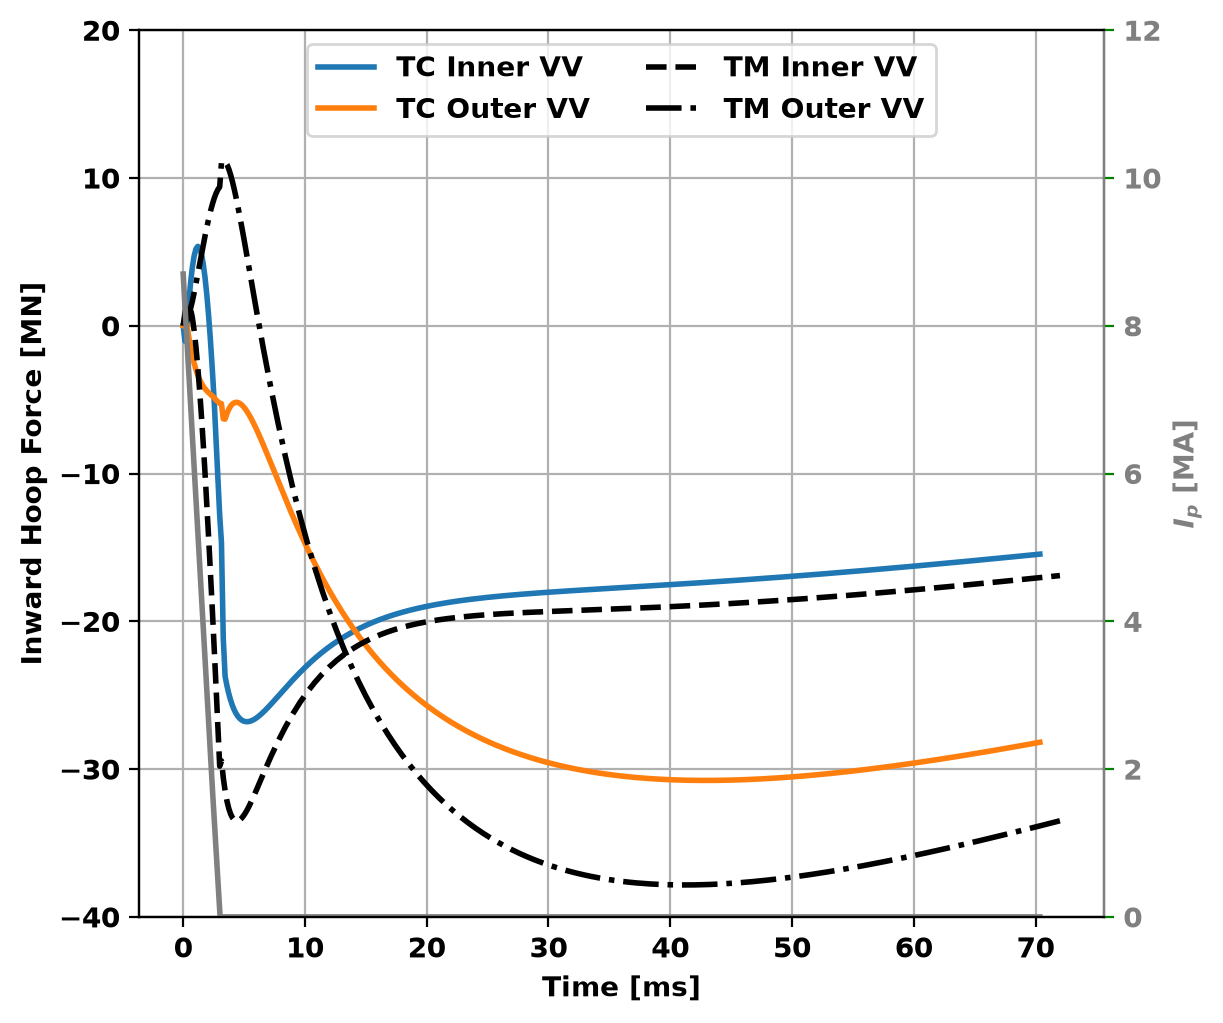

In [16]:
# Plot Ip ramp
fig, ax = plt.subplots(1,1,figsize=(6,5),constrained_layout=True)
ax2 = ax.twinx()
Ip_times = coil_currs[:,0]
Ip = coil_currs[:,-EQ_filaments.shape[0]:].sum(axis=1)
ax2.plot(Ip_times*1.E3,Ip/1.E6,label=r'$I_P$',color='0.5')

# Plot forces
ax.plot(times*1.E3,forces_inner[:,3]/1.E6, label=r'TC Inner VV')
ax.plot(times*1.E3,forces_outer[:,3]/1.E6, label=r'TC Outer VV')

# Plot TokaMaker forces
tMaker_forces = np.loadtxt('TokaMaker_forces.dat')
ax.plot(tMaker_forces[:,0]*1.E3,tMaker_forces[:,1]/1.E6,'k--', label=r'TM Inner VV')
ax.plot(tMaker_forces[:,0]*1.E3,tMaker_forces[:,2]/1.E6,'k-.', label=r'TM Outer VV')

# Format plot
ax.grid(True)
ax.set_ylim(-40,20)
ax2.set_ylim(0,12)
ax.legend(loc='upper center',ncol=2)
ax.set_ylabel(r'Inward Hoop Force [MN]')
ax2.set_ylabel(r'$I_p$ [MA]',color='0.5')
ax2.tick_params(color='green', labelcolor='0.5')
ax2.spines['right'].set_edgecolor('0.5')
_ = ax.set_xlabel(r'Time [ms]')

## Looking at results in ParaView
Now let's explore how to look at the results and make pretty plots in ParaView.